In [1]:
import tensorflow as tf
import numpy as np
import json
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


2026-02-19 13:39:32.536685: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# LOAD MODEL
# -----------------------------
model = tf.keras.models.load_model("/Users/jein/env/env/Fashion_product_intelligence/model/classifier_model_clean.h5")


In [3]:
# DATA GENERATOR (VALIDATION)
# -----------------------------
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_data = datagen.flow_from_directory(
    "/Users/jein/env/env/Fashion_product_intelligence/dataset_clean",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False   # VERY IMPORTANT
)


Found 3719 images belonging to 5 classes.


In [4]:
# LOAD CLASS NAMES
# -----------------------------
class_indices = val_data.class_indices
class_names = list(class_indices.keys())

print("Class names:", class_names)


Class names: ['Casual_Shoes', 'Jeans', 'Shirts', 'Sports_Shoes', 'Tshirts']


In [5]:
# PREDICTIONS
# -----------------------------
y_true = val_data.classes
y_pred_probs = model.predict(val_data)
y_pred = np.argmax(y_pred_probs, axis=1)

# -----------------------------
# ACCURACY
# -----------------------------
accuracy = np.mean(y_true == y_pred)
print("\nOverall Accuracy:", accuracy)


117/117 ━━━━━━━━━━━━━━━━━━━━ 422s 4s/step

Overall Accuracy: 0.9564399031997849


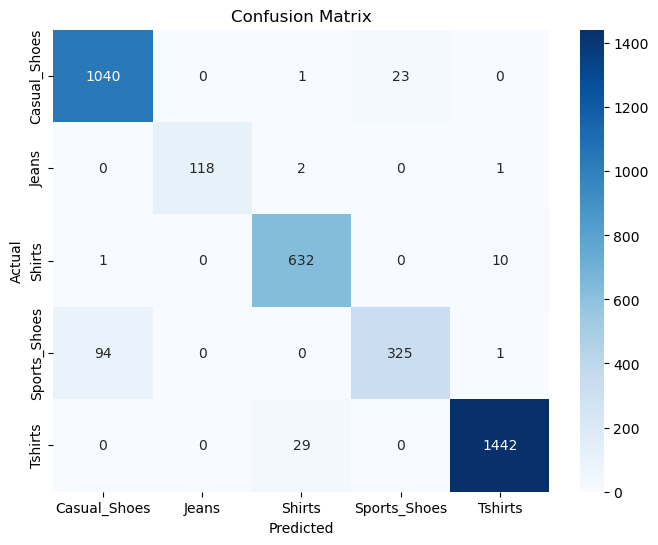

In [6]:
# CONFUSION MATRIX
# -----------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [9]:
#  CLASS-WISE METRICS
# -----------------------------
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print("\nClassification Report:")
print(report)



Classification Report:
              precision    recall  f1-score   support

Casual_Shoes       0.92      0.98      0.95      1064
       Jeans       1.00      0.98      0.99       121
      Shirts       0.95      0.98      0.97       643
Sports_Shoes       0.93      0.77      0.85       420
     Tshirts       0.99      0.98      0.99      1471

    accuracy                           0.96      3719
   macro avg       0.96      0.94      0.95      3719
weighted avg       0.96      0.96      0.96      3719

